# 📝 Instrucciones: Análisis de Sentimientos con Naive Bayes

Los modelos **Naive Bayes** son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.

En este proyecto practicarás con un conjunto de datos para crear un clasificador de reseñas de la tienda de Google Play.

---

## Paso 1: Carga del conjunto de datos

El conjunto de datos se encuentra en el siguiente enlace. Puedes cargarlo directamente o descargarlo:

* **URL:** [playstore_reviews.csv](https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv)

### Variables del Dataset:
* `package_name`: Nombre de la aplicación móvil (categórico).
* `review`: Comentario sobre la aplicación móvil (categórico).
* `polarity`: Variable de clase (0 o 1), siendo **0 negativo** y **1 positivo** (categórico numérico).

---

## Paso 2: Estudio de variables y su contenido

En este caso, tenemos solo 3 variables. Realmente solo nos interesa la parte del comentario (`review`), ya que la clasificación dependerá de su contenido y no del nombre del paquete. Por lo tanto, la variable `package_name` debe ser eliminada.

### Procesamiento de Texto
Antes de entrenar, debemos procesar el texto plano:

1.  **Limpieza:** Eliminar espacios y convertir a minúsculas.
    ```python
    df["column"] = df["column"].str.strip().str.lower()
    ```
2.  **División de datos:** Separar en `X_train`, `X_test`, `y_train`, `y_test`.
3.  **Vectorización:** Transformar el texto en una matriz de recuento de palabras usando `CountVectorizer`.
    ```python
    vec_model = CountVectorizer(stop_words = "english")
    X_train = vec_model.fit_transform(X_train).toarray()
    X_test = vec_model.transform(X_test).toarray()
    ```

---

## Paso 3: Construye un Naive Bayes

Implementa el modelo eligiendo entre las tres variantes principales según lo estudiado:
* `GaussianNB`
* `MultinomialNB`
* `BernoulliNB`

**Tarea:** Entrena las tres implementaciones y compara cuál es la más adecuada para este tipo de datos (conteo de palabras).

---

## Paso 4: Optimiza el modelo anterior

Tras elegir la mejor variante de Naive Bayes, intenta comparar u optimizar los resultados utilizando un **Random Forest** para ver si mejora la precisión.

---

## Paso 5: Guarda el modelo

Almacena el modelo entrenado en la carpeta correspondiente de tu proyecto (por ejemplo, usando `pickle` o `joblib`).

---

## Paso 6: Explora otras alternativas

¿Qué otros modelos de los que hemos estudiado podrías utilizar para intentar superar los resultados de un Naive Bayes? 
* **Argumenta tu respuesta.**
* **Entrena el modelo elegido.**

## TAREA

In [56]:
#importamos librerias

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import ( confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve)
from scipy.stats import randint, loguniform
from sklearn.feature_extraction.text import CountVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

!pip install imblearn


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [57]:
df = pd.read_csv("../data/raw/playstore_reviews.csv")
df

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0
...,...,...,...
886,com.rovio.angrybirds,loved it i loooooooooooooovvved it because it...,1
887,com.rovio.angrybirds,all time legendary game the birthday party le...,1
888,com.rovio.angrybirds,ads are way to heavy listen to the bad review...,0
889,com.rovio.angrybirds,fun works perfectly well. ads aren't as annoy...,1


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB


In [59]:
df.describe(include='all')

,package_name,review,polarity
count,891,891,891.000000
unique,23,891,NaN
top,com.facebook.katana,privacy at least put some option appear offli...,NaN
freq,40,1,NaN
mean,NaN,NaN,0.344557
std,NaN,NaN,0.475490
min,NaN,NaN,0.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,0.000000
75%,NaN,NaN,1.000000


In [60]:
# eliminamos espacios antes y despues de las reviews
df["review"] = df["review"].str.strip().str.lower()
df

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offlin...,0
1,com.facebook.katana,"messenger issues ever since the last update, i...",0
2,com.facebook.katana,profile any time my wife or anybody has more t...,0
3,com.facebook.katana,the new features suck for those of us who don'...,0
4,com.facebook.katana,forced reload on uploading pic on replying com...,0
...,...,...,...
886,com.rovio.angrybirds,loved it i loooooooooooooovvved it because it ...,1
887,com.rovio.angrybirds,all time legendary game the birthday party lev...,1
888,com.rovio.angrybirds,ads are way to heavy listen to the bad reviews...,0
889,com.rovio.angrybirds,fun works perfectly well. ads aren't as annoyi...,1


In [61]:
df.drop('package_name', axis=1, inplace=True)

In [62]:
df

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0
...,...,...
886,loved it i loooooooooooooovvved it because it ...,1
887,all time legendary game the birthday party lev...,1
888,ads are way to heavy listen to the bad reviews...,0
889,fun works perfectly well. ads aren't as annoyi...,1


In [63]:
X = df.drop('polarity',axis=1)
y = df['polarity']

In [64]:
y.value_counts()

polarity
0    584
1    307
Name: count, dtype: int64

In [65]:
# Aplicamos un oversampling 
ros = RandomOverSampler(sampling_strategy="minority",random_state=42)
X_over, y_over = ros.fit_resample(X, y)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_over, y_over, test_size=0.33, random_state=42)

In [67]:
vec_model = CountVectorizer(stop_words = "english")
X_train = X_train['review'].astype(str) 
X_test = X_test['review'].astype(str)
X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()

# Aplicamos el modelo gaussianNB

In [68]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [69]:
y_pred_g = model.predict(X_test)
metrics_GNB = classification_report(y_test, y_pred_g, output_dict = True)
print(classification_report(y_test, y_pred_g))
acc_g = accuracy_score(y_test, y_pred_g)
print(f' El accurracy es de {acc_g}')

              precision    recall  f1-score   support

           0       0.91      0.77      0.83       209
           1       0.77      0.91      0.83       177

    accuracy                           0.83       386
   macro avg       0.84      0.84      0.83       386
weighted avg       0.84      0.83      0.83       386

 El accurracy es de 0.8316062176165803


# Aplicamos el modelo MultinomialNB

In [70]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [71]:
y_pred_m = mnb.predict(X_test)
metrics_mnb = classification_report(y_test, y_pred_m, output_dict = True)
print(classification_report(y_test, y_pred_m))
acc_m = accuracy_score(y_test, y_pred_m)
print(f' El accurracy es de {acc_m}')

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       209
           1       0.83      0.92      0.87       177

    accuracy                           0.88       386
   macro avg       0.88      0.88      0.88       386
weighted avg       0.88      0.88      0.88       386

 El accurracy es de 0.8756476683937824


# Aplicamos el modelo bernoulli 

In [72]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [73]:
y_pred_b = bnb.predict(X_test)
metrics_bnb = classification_report(y_test, y_pred_b, output_dict = True)
print(classification_report(y_test, y_pred_b))
acc_b = accuracy_score(y_test, y_pred_b)
print(f' El accurracy es de {acc_b}')

              precision    recall  f1-score   support

           0       0.93      0.76      0.84       209
           1       0.76      0.94      0.84       177

    accuracy                           0.84       386
   macro avg       0.85      0.85      0.84       386
weighted avg       0.86      0.84      0.84       386

 El accurracy es de 0.8393782383419689


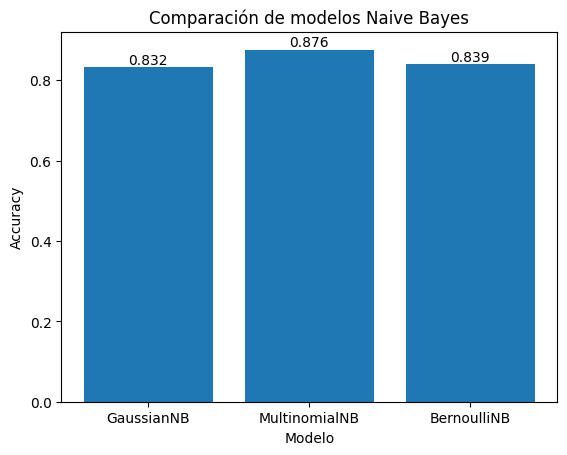

In [74]:

modelos = ['GaussianNB', 'MultinomialNB', 'BernoulliNB']


accuracies = [acc_g, acc_m, acc_b]

plt.figure()
plt.bar(modelos, accuracies)

plt.title('Comparación de modelos Naive Bayes')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')


for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

# Mejoramos el modelo haciendo un grid search


In [75]:
param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1, 2]
}
grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [76]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [77]:
grid.best_params_
best_nb = grid.best_estimator_
y_pred_best = best_nb.predict(X_test)
y_pred_best

array([1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,

In [78]:
acc_gsc = accuracy_score(y_test, y_pred_best)
print(f' El accurracy es de {acc_gsc}')

 El accurracy es de 0.8782383419689119


# Guardamos el modelo


In [79]:
joblib.dump(best_nb, "../models/naive_bayes_model.pkl")
joblib.dump(vec_model, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

## Hagamos el paso del random forest 

In [80]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf
acc_rf= accuracy_score(y_test, y_pred_rf)
print(f' El accurracy es de {acc_rf}')

 El accurracy es de 0.8238341968911918


### Con el modelo Random forest el accuracy no mejora porque en los modelos basados en arboles pierden eficiencia con los datos textuales. Probamos con otros modelos 


## Regresion logistica 

In [81]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
accuracy_score(y_test, lr.predict(X_test))

0.8626943005181347

## Support Vector Machine

In [82]:
svm = LinearSVC()
svm.fit(X_train, y_train)
LinearSVC()
accuracy_score(y_test, svm.predict(X_test))

/home/vscode/.local/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.8575129533678757

El modelo mas optimo seria el MultinomialNB con el mayor grado de accruracy. 